# 04 — Prediction
**Project:** AI-based 5G Alarm Analysis — Djezzy  
**Goal:** Predict High-Severity (HS) alarm events before they occur using non-HS precursor alarms  
**Models:** XGBoost · LightGBM · RandomForest · LogisticRegression  
**Output:** Trained model + SHAP explanations + evaluation report

---

## 0. Imports & Configuration

In [4]:
import sys, os, json, importlib
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score,
    classification_report as clf_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Always reload to pick up any changes to prediction.py
import src.prediction as _pred_module
importlib.reload(_pred_module)

from src.prediction import (
    build_rolling_features,
    prepare_X_y,
    get_models,
    cross_validate_all,
    train_final_model,
    tune_threshold,
    evaluate_model,
    print_evaluation,
    compute_shap_values,
    get_top_shap_features,
    save_model,
    load_model,
    predict_hs,
    train_category_classifier,
    MAPPING_RULES,
    HS_ALARM_NAMES,
    WINDOWS_MIN,
    TOP_PRECURSORS,
    _ensure_columns,
)

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', None)

PARQUET_PATH = '../data/processed/alarms_processed.parquet'
FEATURES_DIR = '../data/features/'
FIGURES_DIR  = '../reports/figures/'
MODELS_DIR   = '../models/'
REPORTS_DIR  = '../reports/'

for d in [FEATURES_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
print('Ready.')
print(f'prediction.py loaded from: {_pred_module.__file__}')

Ready.
prediction.py loaded from: c:\Users\hp\Desktop\PFE Project\src\prediction.py


In [5]:
import inspect
from src.prediction import prepare_X_y
print(inspect.getsource(prepare_X_y))

def prepare_X_y(
    df          : pd.DataFrame,
    rolling_feat: pd.DataFrame,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Assemble the final feature matrix and target vector.

    Features = rolling columns + temporal columns (hour, day_of_week, …).
    No static rate statistics — those leak the label.

    Parameters
    ----------
    df           : raw alarm DataFrame (must have Occurrencetime, is_HS)
    rolling_feat : output of build_rolling_features(), aligned to df's index

    Returns
    -------
    X : numeric DataFrame, no NaNs
    y : binary int array (1 = HS)
    """
    df = _ensure_columns(df)

    temporal = df[[c for c in TEMPORAL_COLS if c in df.columns]].copy()
    X = pd.concat([rolling_feat, temporal], axis=1).fillna(0)
    y = df["is_HS"].astype(int).values

    return X, y



## 1. Load & Prepare Data

In [6]:
df_raw = pd.read_parquet(PARQUET_PATH)
df_raw = _ensure_columns(df_raw)

print(f'Shape      : {df_raw.shape}')
print(f'HS alarms  : {df_raw["is_HS"].sum():,} ({df_raw["is_HS"].mean()*100:.2f}%)')
print(f'Non-HS     : {(~df_raw["is_HS"]).sum():,}')
print(f'Alarm types: {df_raw["Alarmname"].nunique()}')
print(f'Sites      : {df_raw["codesite"].nunique()}')

# Sort by time and lock in a clean 0-based index ONCE.
# Everything downstream (rolling features, X, splits) shares this index.
df = df_raw[df_raw['codesite'].notna()].sort_values('Occurrencetime').reset_index(drop=True)
print(f'After codesite filter: {len(df):,} rows (from {len(df_raw):,})')
print(f'\nSorted and reindexed: {len(df):,} rows, index 0..{len(df)-1}')
df.head(3)

Shape      : (4655881, 31)
HS alarms  : 209,225 (4.49%)
Non-HS     : 4,446,656
Alarm types: 891
Sites      : 7748
After codesite filter: 2,236,253 rows (from 4,655,881)

Sorted and reindexed: 2,236,253 rows, index 0..2236252


,Alarmname,occurrencetime_reg,Businessaffected,codesite,Neobjectidentity,Alarmsource,clear,Clearancetime,Locationinformation,Objectidentityname,Occurrencetime,R Server Id,Severity,Netype,Productname,Status,Type,Clearing Status,Remote Last Update,Logserialnumber,duration_min,is_cleared,hour,day_of_week,date,month,year,is_night,is_weekend,is_HS,hs_category
0,ALD Maintenance Link Failure,2017-07-14 19:27:58,nan,A16X727,NE=10937,MBTS_A16X727,Cleared,2017-11-13 17:19:52+01:00,"Device No.=53, Device Type=TMA",MBTS_A16X727,2017-07-14 19:27:58+01:00,2,Major,BTS3900 WCDMA,Mobile,Unacknowledged and cleared Alarm,Communication system,Cleared,2025-09-26 11:10:00,114909213,175551.9,True,19.0,4.0,2017-07-14,7.0,2017.0,0,0,False,Non-HS
1,ALD Maintenance Link Failure,2017-07-14 19:27:58,nan,A16X727,NE=10937,MBTS_A16X727,Cleared,2017-11-13 17:19:52+01:00,"Device No.=7, Device Type=RET",MBTS_A16X727,2017-07-14 19:27:58+01:00,2,Major,BTS3900 WCDMA,Mobile,Unacknowledged and cleared Alarm,Communication system,Cleared,2025-09-26 11:10:00,114909210,175551.9,True,19.0,4.0,2017-07-14,7.0,2017.0,0,0,False,Non-HS
2,ALD Maintenance Link Failure,2017-07-14 19:27:58,nan,A16X727,NE=10937,MBTS_A16X727,Cleared,2017-11-13 17:19:52+01:00,"Device No.=8, Device Type=RET",MBTS_A16X727,2017-07-14 19:27:58+01:00,2,Major,BTS3900 WCDMA,Mobile,Unacknowledged and cleared Alarm,Communication system,Cleared,2025-09-26 11:10:00,114909211,175551.9,True,19.0,4.0,2017-07-14,7.0,2017.0,0,0,False,Non-HS


## 2. Rolling Window Features
> Computed once on the full dataset. Window = **[t-W, t)** — the current event  
> is excluded so features only reflect **past** activity (no label leakage).  
> Cache is validated on every load — stale cache is deleted automatically.

In [7]:
ROLLING_CACHE   = FEATURES_DIR + 'rolling_features.parquet'
PRECURSOR_CACHE = FEATURES_DIR + 'top_precursor_alarms.json'

for f in [ROLLING_CACHE, PRECURSOR_CACHE]:
    if os.path.exists(f): os.remove(f)

def _cache_is_valid(cache_path, df):
    """Return True only if the cached rolling features align with df's index."""
    if not os.path.exists(cache_path):
        return False
    try:
        cached = pd.read_parquet(cache_path)
        # Must have the same length and the same index values
        return (len(cached) == len(df) and
                (cached.index == df.index).all() and
                cached['n_hs_60m'].iloc[int(len(df)*0.85):].mean() > 0)
    except Exception:
        return False

if _cache_is_valid(ROLLING_CACHE, df) and os.path.exists(PRECURSOR_CACHE):
    print('Loading validated cache...')
    rolling_feat         = pd.read_parquet(ROLLING_CACHE)
    top_precursor_alarms = json.load(open(PRECURSOR_CACHE))
else:
    print('Cache missing or invalid — rebuilding...')
    # Delete stale files
    for f in [ROLLING_CACHE, PRECURSOR_CACHE]:
        if os.path.exists(f): os.remove(f)

    # Use Phase 2/3 precursor rankings if available
    PRECURSOR_RANKINGS = FEATURES_DIR + 'precursor_rankings.csv'
    if os.path.exists(PRECURSOR_RANKINGS):
        prec_df = pd.read_csv(PRECURSOR_RANKINGS)
        top_precursor_alarms = (
            prec_df.groupby('precursor_alarm')['count']
            .sum().sort_values(ascending=False)
            .head(TOP_PRECURSORS).index.tolist()
        )
    else:
        top_precursor_alarms = None

    
    rolling_feat, top_precursor_alarms = build_rolling_features(
        df, windows_min=WINDOWS_MIN,
        top_precursor_alarms=top_precursor_alarms,
    )
    rolling_feat.to_parquet(ROLLING_CACHE)
    json.dump(top_precursor_alarms, open(PRECURSOR_CACHE, 'w'))
    print(f'Saved → {ROLLING_CACHE}')

print(f'Shape  : {rolling_feat.shape}')
print(f'Index  : {rolling_feat.index.min()} .. {rolling_feat.index.max()}')
print(f'Aligns : {(rolling_feat.index == df.index).all()}')
print(f'Top precursors: {top_precursor_alarms}')
rolling_feat.head(3)

Cache missing or invalid — rebuilding...
  Rolling features: 7,748 sites | 2,236,253 events | 125 columns


  Sites: 100%|███████████████████████████| 7748/7748 [00:36<00:00, 213.24site/s]


Saved → ../data/features/rolling_features.parquet
Shape  : (2236253, 125)
Index  : 0 .. 2236252
Aligns : False
Top precursors: ['SCTP Link Fault', 'Adjacent Node IP Address Ping Failure', 'UMTS Cell MC-HSDPA Function Fault', 'ESL Link Fault', 'Commercial Power Down (Main Power Down)', 'Base Station DC Power Supply Abnormal', 'RF Unit Maintenance Link Failure', 'E1/T1 Alarm Indication Signal', 'The Data Transmission Channel Between the Trace Server and the NE Is Disrupted', 'Cell Outage', 'Statistical Alarm', 'Task execution failure alarm', 'SDH/SONET TU Alarm Indication Signal', 'GTPC Tunnel Path Broken', 'SDH/SONET Tributary Alarm Indication Signal', 'RF Unit RX Channel RTWP/RSSI Unbalanced', 'Path Fault', 'Local Cell Unusable', 'Parallel Alarm Exceeds the Limit', 'Air Cond. Alarm']


,n_total_5m,n_hs_5m,n_unique_5m,rate_5m,hs_rate_5m,prec_SCTP_Link_Fault_5m,prec_Adjacent_Node_IP_Address_Ping__5m,prec_UMTS_Cell_MC-HSDPA_Function_Fa_5m,prec_ESL_Link_Fault_5m,prec_Commercial_Power_Down_(Main_Po_5m,prec_Base_Station_DC_Power_Supply_A_5m,prec_RF_Unit_Maintenance_Link_Failu_5m,prec_E1_T1_Alarm_Indication_Signal_5m,prec_The_Data_Transmission_Channel__5m,prec_Cell_Outage_5m,prec_Statistical_Alarm_5m,prec_Task_execution_failure_alarm_5m,prec_SDH_SONET_TU_Alarm_Indication__5m,prec_GTPC_Tunnel_Path_Broken_5m,prec_SDH_SONET_Tributary_Alarm_Indi_5m,prec_RF_Unit_RX_Channel_RTWP_RSSI_U_5m,prec_Path_Fault_5m,prec_Local_Cell_Unusable_5m,prec_Parallel_Alarm_Exceeds_the_Lim_5m,prec_Air_Cond._Alarm_5m,n_total_15m,n_hs_15m,n_unique_15m,rate_15m,hs_rate_15m,prec_SCTP_Link_Fault_15m,prec_Adjacent_Node_IP_Address_Ping__15m,prec_UMTS_Cell_MC-HSDPA_Function_Fa_15m,prec_ESL_Link_Fault_15m,prec_Commercial_Power_Down_(Main_Po_15m,prec_Base_Station_DC_Power_Supply_A_15m,prec_RF_Unit_Maintenance_Link_Failu_15m,prec_E1_T1_Alarm_Indication_Signal_15m,prec_The_Data_Transmission_Channel__15m,prec_Cell_Outage_15m,prec_Statistical_Alarm_15m,prec_Task_execution_failure_alarm_15m,prec_SDH_SONET_TU_Alarm_Indication__15m,prec_GTPC_Tunnel_Path_Broken_15m,prec_SDH_SONET_Tributary_Alarm_Indi_15m,prec_RF_Unit_RX_Channel_RTWP_RSSI_U_15m,prec_Path_Fault_15m,prec_Local_Cell_Unusable_15m,prec_Parallel_Alarm_Exceeds_the_Lim_15m,prec_Air_Cond._Alarm_15m,n_total_30m,n_hs_30m,n_unique_30m,rate_30m,hs_rate_30m,prec_SCTP_Link_Fault_30m,prec_Adjacent_Node_IP_Address_Ping__30m,prec_UMTS_Cell_MC-HSDPA_Function_Fa_30m,prec_ESL_Link_Fault_30m,prec_Commercial_Power_Down_(Main_Po_30m,prec_Base_Station_DC_Power_Supply_A_30m,prec_RF_Unit_Maintenance_Link_Failu_30m,prec_E1_T1_Alarm_Indication_Signal_30m,prec_The_Data_Transmission_Channel__30m,prec_Cell_Outage_30m,prec_Statistical_Alarm_30m,prec_Task_execution_failure_alarm_30m,prec_SDH_SONET_TU_Alarm_Indication__30m,prec_GTPC_Tunnel_Path_Broken_30m,prec_SDH_SONET_Tributary_Alarm_Indi_30m,prec_RF_Unit_RX_Channel_RTWP_RSSI_U_30m,prec_Path_Fault_30m,prec_Local_Cell_Unusable_30m,prec_Parallel_Alarm_Exceeds_the_Lim_30m,prec_Air_Cond._Alarm_30m,n_total_60m,n_hs_60m,n_unique_60m,rate_60m,hs_rate_60m,prec_SCTP_Link_Fault_60m,prec_Adjacent_Node_IP_Address_Ping__60m,prec_UMTS_Cell_MC-HSDPA_Function_Fa_60m,prec_ESL_Link_Fault_60m,prec_Commercial_Power_Down_(Main_Po_60m,prec_Base_Station_DC_Power_Supply_A_60m,prec_RF_Unit_Maintenance_Link_Failu_60m,prec_E1_T1_Alarm_Indication_Signal_60m,prec_The_Data_Transmission_Channel__60m,prec_Cell_Outage_60m,prec_Statistical_Alarm_60m,prec_Task_execution_failure_alarm_60m,prec_SDH_SONET_TU_Alarm_Indication__60m,prec_GTPC_Tunnel_Path_Broken_60m,prec_SDH_SONET_Tributary_Alarm_Indi_60m,prec_RF_Unit_RX_Channel_RTWP_RSSI_U_60m,prec_Path_Fault_60m,prec_Local_Cell_Unusable_60m,prec_Parallel_Alarm_Exceeds_the_Lim_60m,prec_Air_Cond._Alarm_60m,n_total_1440m,n_hs_1440m,n_unique_1440m,rate_1440m,hs_rate_1440m,prec_SCTP_Link_Fault_1440m,prec_Adjacent_Node_IP_Address_Ping__1440m,prec_UMTS_Cell_MC-HSDPA_Function_Fa_1440m,prec_ESL_Link_Fault_1440m,prec_Commercial_Power_Down_(Main_Po_1440m,prec_Base_Station_DC_Power_Supply_A_1440m,prec_RF_Unit_Maintenance_Link_Failu_1440m,prec_E1_T1_Alarm_Indication_Signal_1440m,prec_The_Data_Transmission_Channel__1440m,prec_Cell_Outage_1440m,prec_Statistical_Alarm_1440m,prec_Task_execution_failure_alarm_1440m,prec_SDH_SONET_TU_Alarm_Indication__1440m,prec_GTPC_Tunnel_Path_Broken_1440m,prec_SDH_SONET_Tributary_Alarm_Indi_1440m,prec_RF_Unit_RX_Channel_RTWP_RSSI_U_1440m,prec_Path_Fault_1440m,prec_Local_Cell_Unusable_1440m,prec_Parallel_Alarm_Exceeds_the_Lim_1440m,prec_Air_Cond._Alarm_1440m
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

## 3. Build Feature Matrix
> Features = rolling columns + temporal columns.  
> No static alarm/site rate statistics — those leak the label.

In [8]:
X, y = prepare_X_y(df, rolling_feat)

X['burst_ratio_5_60']   = X['n_total_5m']  / X['n_total_60m'].clip(lower=1)
X['burst_ratio_5_1440'] = X['n_total_5m']  / X['n_total_1440m'].clip(lower=1)
X['hs_burst_5_60']      = X['n_hs_5m']     / X['n_hs_60m'].clip(lower=1)
X['hs_burst_60_1440']   = X['n_hs_60m']    / X['n_hs_1440m'].clip(lower=1)

n         = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

print(f'Feature matrix : {X.shape[0]:,} rows x {X.shape[1]} columns')
print(f'\n{"Split":<8} {"Rows":>10} {"HS%":>8} {"n_hs_60m":>12} {"n_hs_1440m":>12}')
print('-' * 54)
for name, sl in [('Train', slice(0, train_end)),
                 ('Val',   slice(train_end, val_end)),
                 ('Test',  slice(val_end, None))]:
    rows = X.iloc[sl]
    print(f'{name:<8} {len(rows):>10,} {y[sl].mean()*100:>7.2f}%'
          f' {rows["n_hs_60m"].mean():>12.4f}')

# Hard stop if rolling features are zero in val/test
assert X.iloc[train_end:val_end]['n_hs_60m'].mean() > 0, \
    "Val rolling features are zero — index mismatch in rolling cache!"
assert X.iloc[val_end:]['n_hs_60m'].mean() > 0, \
    "Test rolling features are zero — index mismatch in rolling cache!"
print('\nAlignment verified.')

Feature matrix : 2,236,253 rows x 134 columns

Split          Rows      HS%     n_hs_60m   n_hs_1440m
------------------------------------------------------
Train     1,565,377    4.31%       1.5754
Val         335,438    5.77%       2.1552
Test        335,438    4.54%       1.2297

Alignment verified.


## 4. Feature Correlation Overview
> Sanity check on training portion only — no test data involved.

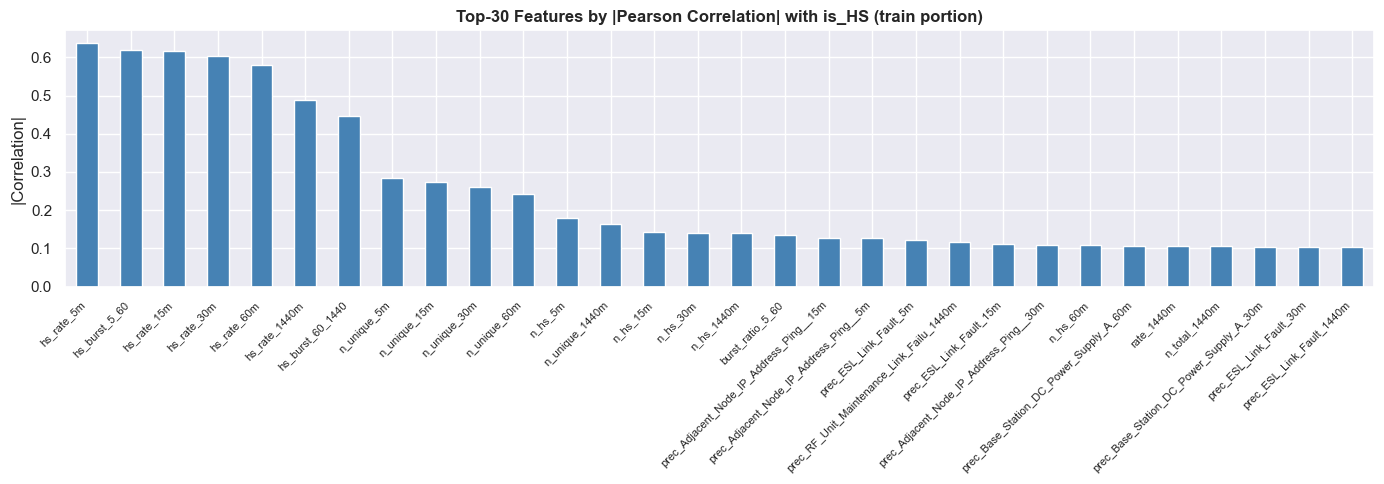

WARNING — suspiciously correlated features:
hs_rate_5m       0.638445
hs_burst_5_60    0.620212
hs_rate_15m      0.617395
hs_rate_30m      0.602942
hs_rate_60m      0.580465
dtype: float64


In [9]:
X_peek = X.iloc[:train_end]
y_peek = y[:train_end]

feat_corr = (
    X_peek.corrwith(pd.Series(y_peek, index=X_peek.index))
    .abs().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
feat_corr.head(30).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top-30 Features by |Pearson Correlation| with is_HS (train portion)',
             fontweight='bold')
ax.set_ylabel('|Correlation|')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_feature_correlation.png', dpi=150)
plt.show()

suspicious = feat_corr[feat_corr > 0.5]
if len(suspicious):
    print('WARNING — suspiciously correlated features:')
    print(suspicious)
else:
    print('No feature correlates > 0.5 with target. Leakage check passed.')

## 5. Train / Validation / Test Split
> Time-based 70 / 15 / 15. X is already sorted chronologically.

In [10]:
X_train, y_train = X.iloc[:train_end],        y[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],          y[val_end:]

scale_pos_weight = (y_train == 0).sum() / max(y_train.sum(), 1)

print(f'Train : {len(X_train):,}  HS={y_train.mean()*100:.2f}%')
print(f'Val   : {len(X_val):,}  HS={y_val.mean()*100:.2f}%')
print(f'Test  : {len(X_test):,}  HS={y_test.mean()*100:.2f}%')
print(f'scale_pos_weight : {scale_pos_weight:.1f}')

Train : 1,565,377  HS=4.31%
Val   : 335,438  HS=5.77%
Test  : 335,438  HS=4.54%
scale_pos_weight : 22.2


## 6. Model Selection — Cross-Validation
> `TimeSeriesSplit` (5 folds) on training set only.  
> No SMOTE in CV — class weights handle imbalance without the memory cost.

In [11]:
print('Cross-validating all models...')
cv_summary = cross_validate_all(
    X_train, y_train,
    scale_pos_weight=scale_pos_weight,
    n_splits=5,
)
cv_summary

Cross-validating all models...
  CV XGBoost...
    ROC-AUC=0.9175  PR-AUC=0.6816  F1=0.5992
  CV LightGBM...
    ROC-AUC=0.9201  PR-AUC=0.6817  F1=0.6009
  CV RandomForest...
    ROC-AUC=0.9216  PR-AUC=0.6667  F1=0.6213
  CV LogisticRegression...
    ROC-AUC=0.8955  PR-AUC=0.5892  F1=0.5834


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std
0,LightGBM,0.920110,0.014934,0.681669,0.043938,0.600936,0.041885
1,XGBoost,0.917539,0.015487,0.681566,0.038921,0.599197,0.044385
2,RandomForest,0.921639,0.012329,0.666727,0.044094,0.621300,0.027581
3,LogisticRegression,0.895494,0.014469,0.589233,0.041557,0.583404,0.028956


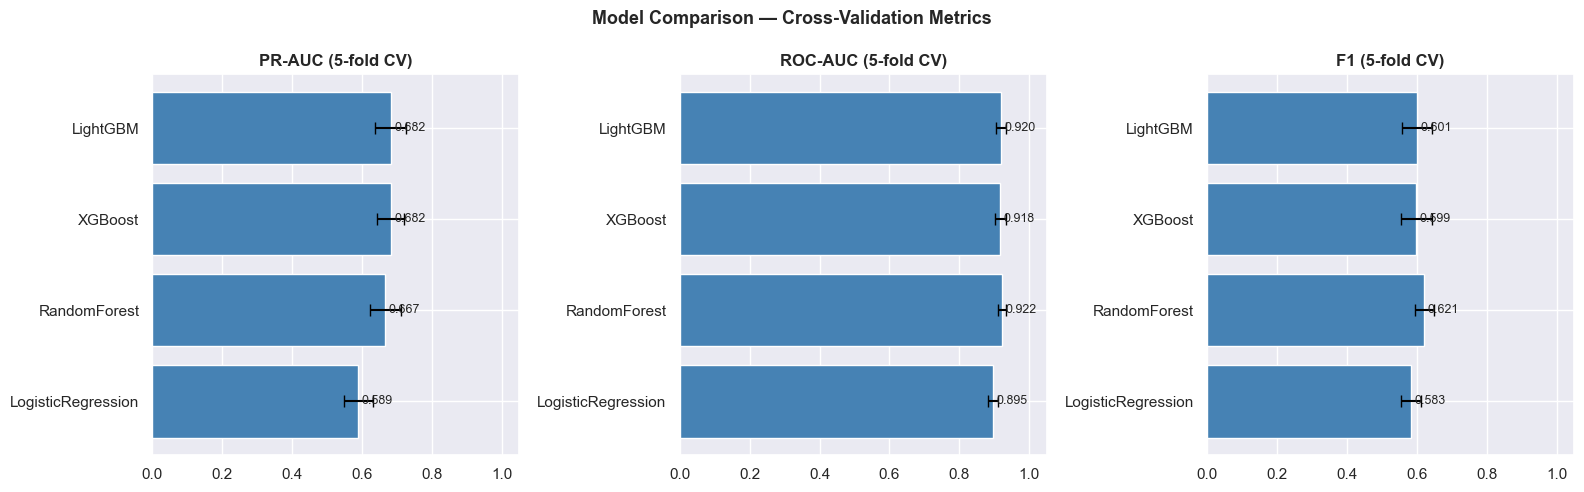

Best model by PR-AUC: LightGBM


In [12]:
metrics_to_plot = ['pr_auc_mean', 'roc_auc_mean', 'f1_mean']
labels          = ['PR-AUC (5-fold CV)', 'ROC-AUC (5-fold CV)', 'F1 (5-fold CV)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, label in zip(axes, metrics_to_plot, labels):
    err  = col.replace('mean', 'std')
    bars = ax.barh(cv_summary['model'], cv_summary[col],
                   xerr=cv_summary[err], color='steelblue',
                   ecolor='black', capsize=4)
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.invert_yaxis()
    for bar, v in zip(bars, cv_summary[col]):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Cross-Validation Metrics',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_cv_comparison.png', dpi=150)
plt.show()

best_model_name = cv_summary.iloc[0]['model']
print(f'Best model by PR-AUC: {best_model_name}')

## 7. Train Final Model
> SMOTE applied here — safe, no validation fold to pollute.

In [13]:
model = train_final_model(
    X_train, y_train,
    model_name       = best_model_name,
    scale_pos_weight = scale_pos_weight,
    use_smote        = True,
)

  Applying SMOTE (sampling_strategy=0.1)...
  After SMOTE: 1,647,774 rows  HS=149,797 (9.1%)
  Fitting LightGBM on 1,647,774 rows...
  Done.


## 8. Threshold Tuning on Validation Set
> Maximise F2 (recall weighted 2×) — missing an HS event costs more than a false alert.

Optimal threshold : 0.8657  →  F2 = 0.6557


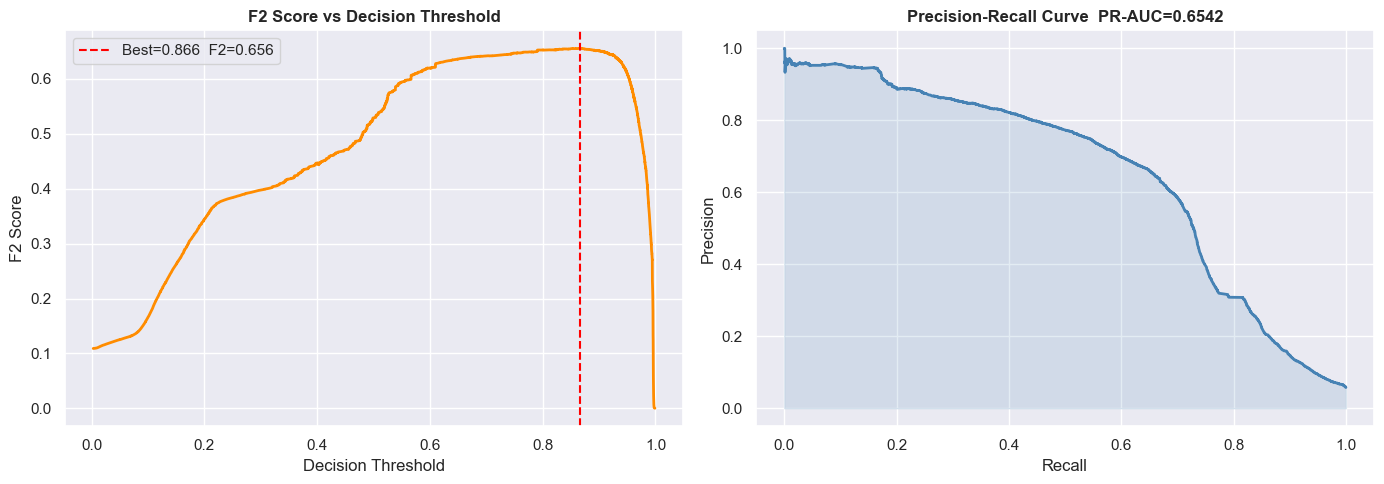

In [14]:
val_proba = model.predict_proba(X_val.values.astype('float32'))[:, 1]
best_threshold, best_f2 = tune_threshold(y_val, val_proba, beta=1)
print(f'Optimal threshold : {best_threshold:.4f}  →  F2 = {best_f2:.4f}')

precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
beta = 1
f2_scores = (
    (1 + beta**2) * precision[:-1] * recall[:-1]
    / np.maximum(beta**2 * precision[:-1] + recall[:-1], 1e-9)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, f2_scores, color='darkorange', lw=2)
axes[0].axvline(best_threshold, color='red', ls='--',
                label=f'Best={best_threshold:.3f}  F2={best_f2:.3f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('F2 Score')
axes[0].set_title('F2 Score vs Decision Threshold', fontweight='bold')
axes[0].legend()

axes[1].plot(recall, precision, color='steelblue', lw=2)
axes[1].fill_between(recall, precision, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(
    f'Precision-Recall Curve  PR-AUC={average_precision_score(y_val, val_proba):.4f}',
    fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_threshold_tuning.png', dpi=150)
plt.show()

## 9. Evaluation on Held-Out Test Set

In [15]:
test_metrics = evaluate_model(
    model, X_test, y_test,
    threshold=best_threshold, model_name=best_model_name,
)
print_evaluation(test_metrics)
test_proba = test_metrics.pop('proba')
test_pred  = (test_proba >= best_threshold).astype(int)


  Evaluation — LightGBM  (threshold=0.866)
  ROC-AUC   : 0.9251
  PR-AUC    : 0.6746
  F1  (HS)  : 0.6640
  F2  (HS)  : 0.6502
  Precision : 0.6883
  Recall    : 0.6413
  Accuracy  : 0.9705

  Confusion Matrix  TP=9766  FP=4423  FN=5462  TN=315787



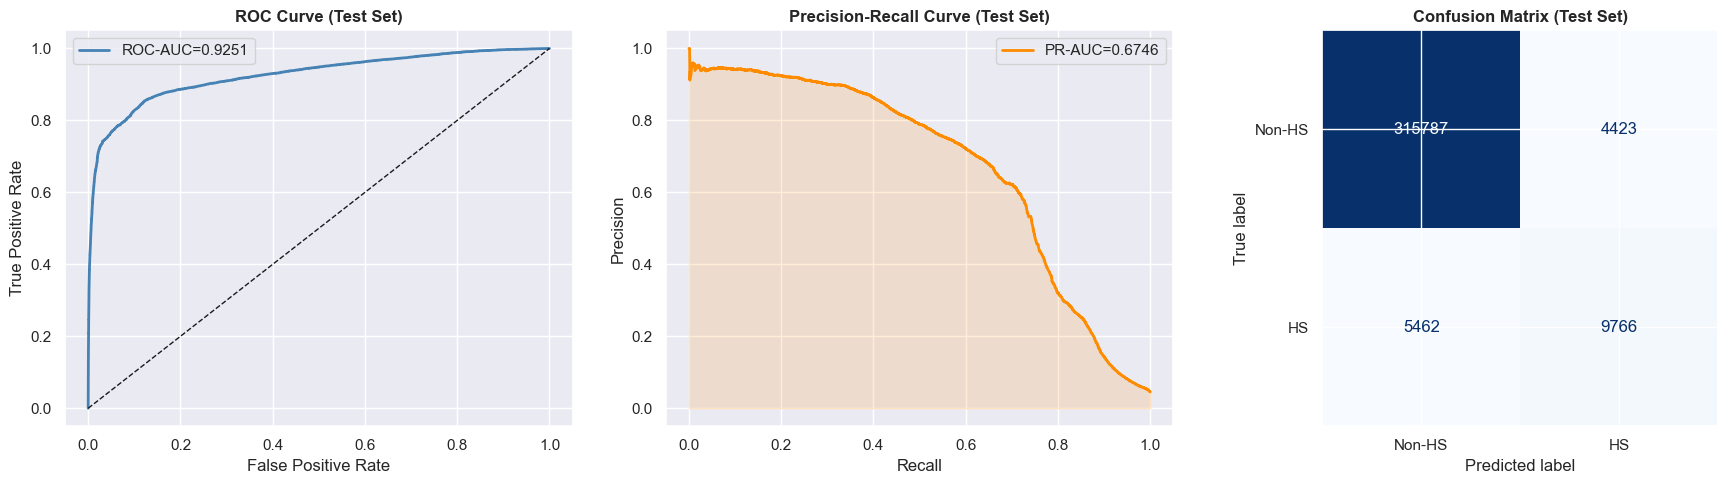

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC-AUC={test_metrics["roc_auc"]:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(rec, prec, color='darkorange', lw=2,
             label=f'PR-AUC={test_metrics["pr_auc"]:.4f}')
axes[1].fill_between(rec, prec, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set)', fontweight='bold')
axes[1].legend()

ConfusionMatrixDisplay(
    test_metrics['confusion_matrix'], display_labels=['Non-HS','HS']
).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_test_evaluation.png', dpi=150)
plt.show()

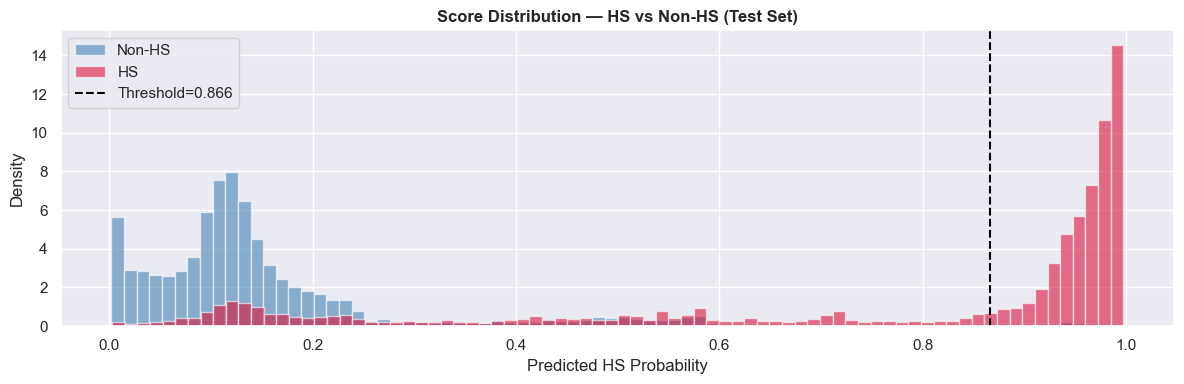

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(test_proba[y_test==0], bins=80, alpha=0.6, color='steelblue',
        label='Non-HS', density=True)
ax.hist(test_proba[y_test==1], bins=80, alpha=0.6, color='crimson',
        label='HS', density=True)
ax.axvline(best_threshold, color='black', ls='--', lw=1.5,
           label=f'Threshold={best_threshold:.3f}')
ax.set_xlabel('Predicted HS Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — HS vs Non-HS (Test Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_score_distribution.png', dpi=150)
plt.show()

## 10. All-Models Comparison on Test Set

  Applying SMOTE (sampling_strategy=0.1)...
  After SMOTE: 1,647,774 rows  HS=149,797 (9.1%)
  Fitting XGBoost on 1,647,774 rows...
  Done.
  Applying SMOTE (sampling_strategy=0.1)...
  After SMOTE: 1,647,774 rows  HS=149,797 (9.1%)
  Fitting LightGBM on 1,647,774 rows...
  Done.
  Applying SMOTE (sampling_strategy=0.1)...
  After SMOTE: 1,647,774 rows  HS=149,797 (9.1%)
  Fitting RandomForest on 1,647,774 rows...
  Done.
  Applying SMOTE (sampling_strategy=0.1)...
  After SMOTE: 1,647,774 rows  HS=149,797 (9.1%)
  Fitting LogisticRegression on 1,647,774 rows...
  Done.


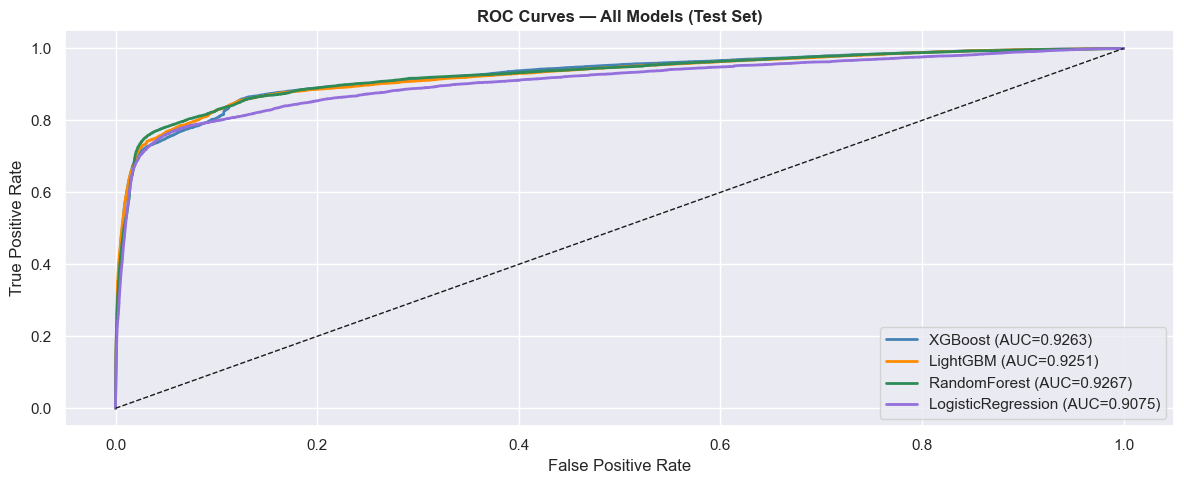

,Model,ROC-AUC,PR-AUC,F1 (HS),F2 (HS),Recall,Precision,Threshold
0,XGBoost,0.9263,0.6666,0.6617,0.6711,0.6776,0.6465,0.890
1,LightGBM,0.9251,0.6746,0.6640,0.6502,0.6413,0.6883,0.866
2,RandomForest,0.9267,0.6597,0.6656,0.6926,0.7118,0.6251,0.734
3,LogisticRegression,0.9075,0.6197,0.6520,0.6592,0.6641,0.6403,0.877


In [18]:
comparison_rows = []
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['steelblue','darkorange','seagreen','mediumpurple']

for model_name_i, color in zip(get_models().keys(), colors):
    m_i      = train_final_model(X_train, y_train, model_name=model_name_i,
                                 scale_pos_weight=scale_pos_weight, use_smote=True)
    val_p_i  = m_i.predict_proba(X_val.values.astype('float32'))[:, 1]
    thr_i, _ = tune_threshold(y_val, val_p_i, beta=1)
    met_i    = evaluate_model(m_i, X_test, y_test,
                              threshold=thr_i, model_name=model_name_i)
    met_i.pop('proba')

    comparison_rows.append({
        'Model'    : model_name_i,
        'ROC-AUC'  : f"{met_i['roc_auc']:.4f}",
        'PR-AUC'   : f"{met_i['pr_auc']:.4f}",
        'F1 (HS)'  : f"{met_i['f1_hs']:.4f}",
        'F2 (HS)'  : f"{met_i['f2_hs']:.4f}",
        'Recall'   : f"{met_i['recall_hs']:.4f}",
        'Precision': f"{met_i['precision_hs']:.4f}",
        'Threshold': f"{thr_i:.3f}",
    })

    fpr_i, tpr_i, _ = roc_curve(
        y_test, m_i.predict_proba(X_test.values.astype('float32'))[:, 1])
    ax.plot(fpr_i, tpr_i, lw=2, color=color,
            label=f"{model_name_i} (AUC={met_i['roc_auc']:.4f})")

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (Test Set)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_roc_all_models.png', dpi=150)
plt.show()

pd.DataFrame(comparison_rows)

## 11. SHAP Explainability

In [19]:
shap_sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
print(f'Computing SHAP on {len(shap_sample):,} samples...')
shap_vals = compute_shap_values(model, shap_sample, model_name=best_model_name)
print('Done.')

Computing SHAP on 1,000 samples...
Done.


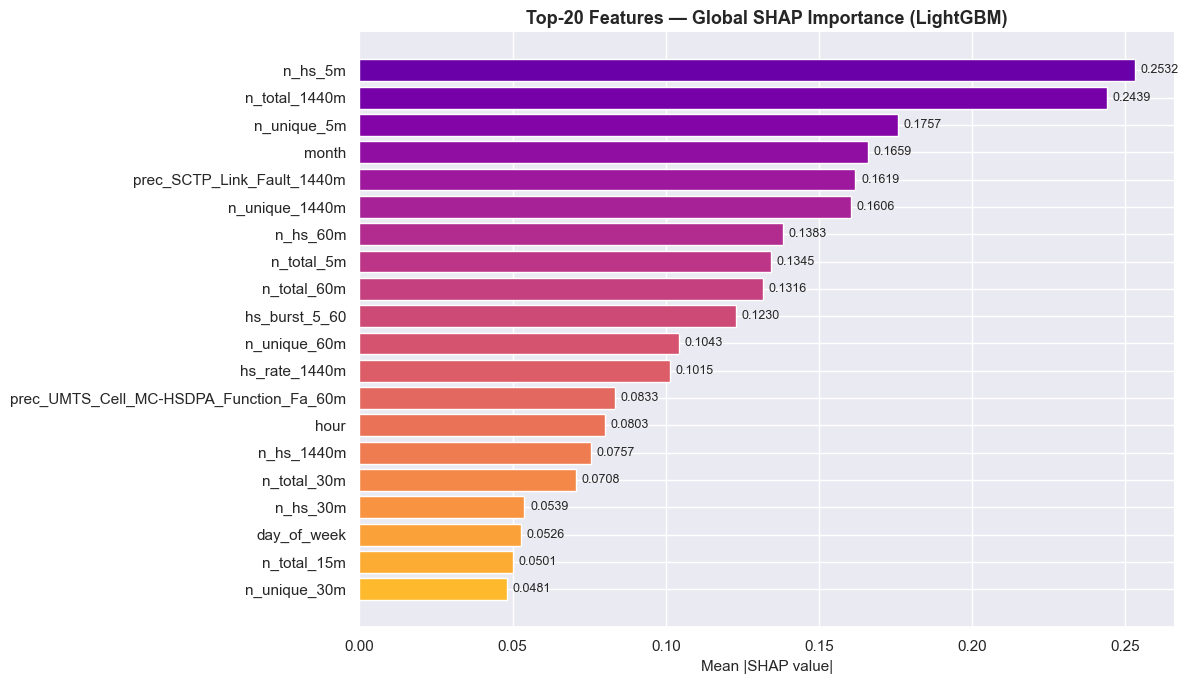

In [20]:
feature_names = X.columns.tolist()
top_feats = get_top_shap_features(shap_vals, feature_names, top_n=20)

fig, ax = plt.subplots(figsize=(12, 7))
colors_shap = plt.cm.plasma(np.linspace(0.2, 0.85, len(top_feats)))
bars = ax.barh(top_feats['feature'], top_feats['mean_shap'], color=colors_shap)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'Top-20 Features — Global SHAP Importance ({best_model_name})',
             fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='{:.4f}', padding=4, fontsize=9)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_shap_bar.png', dpi=150)
plt.show()

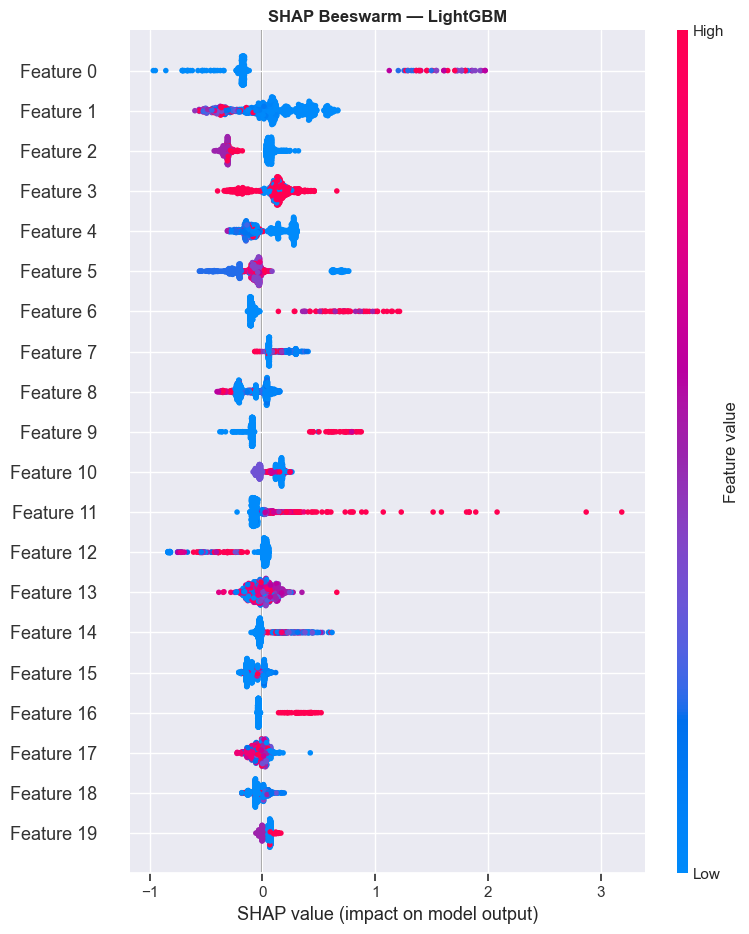

In [21]:
top20_cols = top_feats['feature'].tolist()
col_idx = [feature_names.index(c) for c in top20_cols]

if hasattr(shap_vals, 'values'):
    shap_top = shap_vals[:, col_idx]
else:
    col_idx  = [feature_names.index(c) for c in top20_cols]
    shap_top = shap.Explanation(
        values        = np.array(shap_vals)[:, col_idx],
        data          = shap_sample[top20_cols].values,
        feature_names = top20_cols,
    )

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_top, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — {best_model_name}', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

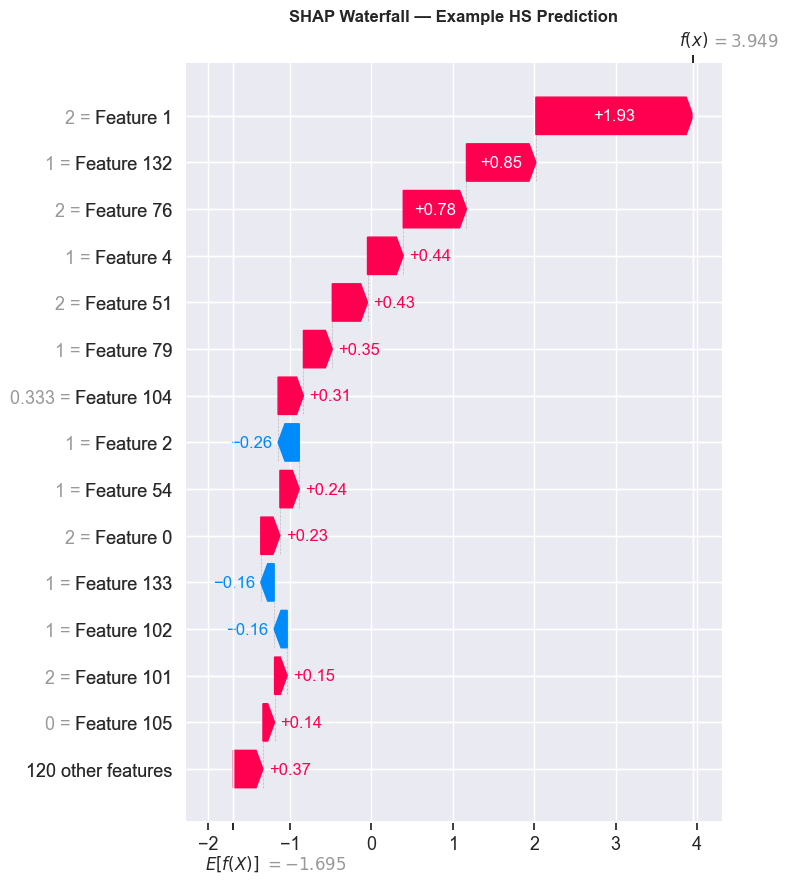

In [22]:
if hasattr(shap_vals, 'values'):
    y_test_sample = y_test[X_test.index.get_indexer(shap_sample.index)]
    hs_indices    = [i for i, v in enumerate(y_test_sample) if v == 1]
    if hs_indices:
        plt.figure()
        shap.plots.waterfall(shap_vals[hs_indices[0]], max_display=15, show=False)
        plt.title('SHAP Waterfall — Example HS Prediction', fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR + 'pred_shap_waterfall.png', dpi=150, bbox_inches='tight')
        plt.show()

In [23]:
for feat in top_feats['feature'].tolist()[:2]:
    shap_vals.feature_names = feature_names
    feat_idx = feature_names.index(feat)
    plt.figure(figsize=(10, 4))
    if hasattr(shap_vals, 'values'):
        shap.plots.scatter(shap_vals[:, feat_idx], show=False)
    plt.title(f'SHAP Dependence — {feat}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + f'pred_shap_dep_{feat[:30]}.png', dpi=150, bbox_inches='tight')

## 12. Per-Window Feature Importance

<Figure size 1000x400 with 0 Axes>

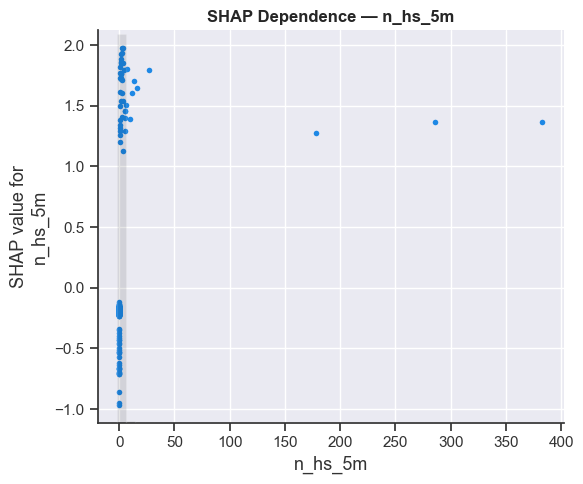

<Figure size 1000x400 with 0 Axes>

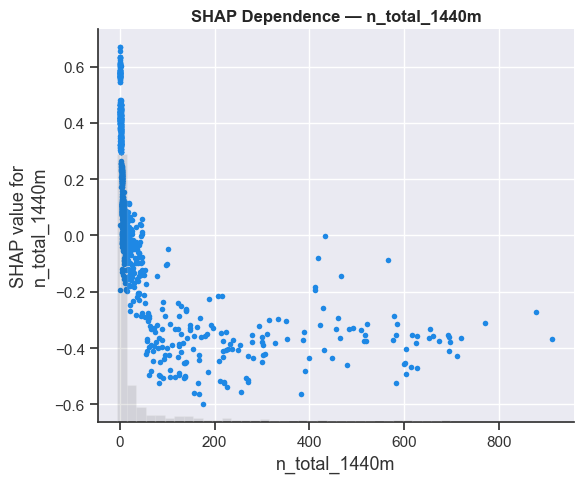

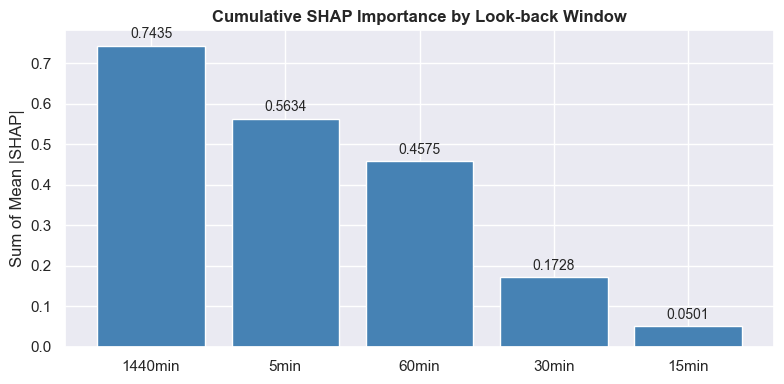

1440min    0.743526
5min       0.563382
60min      0.457545
30min      0.172800
15min      0.050142


In [24]:
window_importance = {}
for w in WINDOWS_MIN:
    cols_w = [c for c in top_feats['feature'] if f'_{w}m' in c]
    window_importance[f'{w}min'] = (
        top_feats[top_feats['feature'].isin(cols_w)]['mean_shap'].sum()
    )

wi_series = pd.Series(window_importance).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wi_series.index, wi_series.values, color='steelblue')
ax.set_title('Cumulative SHAP Importance by Look-back Window', fontweight='bold')
ax.set_ylabel('Sum of Mean |SHAP|')
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_shap_window_importance.png', dpi=150)
plt.show()
print(wi_series.to_string())

## 13. Evaluation by HS Category

In [25]:
# Use df (sorted, 0-based index) — same as what X was built from
test_df = df.iloc[val_end:].copy()
test_df['hs_proba']     = test_proba
test_df['hs_predicted'] = test_pred
test_df['y_true']       = y_test

cat_rows = []
for cat, cat_df in test_df[test_df['is_HS']].groupby('hs_category'):
    y_t     = cat_df['y_true'].values
    y_p     = cat_df['hs_predicted'].values
    proba_c = cat_df['hs_proba'].values
    cat_rows.append({
        'HS Category': cat,
        'N alarms'   : len(y_t),
        'Recall'     : f'{y_p.mean():.3f}',
        'F1'         : f'{f1_score(y_t, y_p, zero_division=0):.3f}',
        'F2'         : f'{fbeta_score(y_t, y_p, beta=1, zero_division=0):.3f}',
        'Mean Proba' : f'{proba_c.mean():.3f}',
    })

cat_eval_df = pd.DataFrame(cat_rows)
print('=== Per-Category Evaluation ===')
cat_eval_df

=== Per-Category Evaluation ===


,HS Category,N alarms,Recall,F1,F2,Mean Proba
0,2G cell down,3848,0.583,0.737,0.737,0.693
1,3G cell down,5935,0.774,0.872,0.872,0.868
2,4G cell down,2195,0.600,0.750,0.750,0.759
3,LOSS-OF-ALL CHANNEL,2094,0.681,0.810,0.810,0.799
4,Pas De Supervision,1156,0.164,0.282,0.282,0.394


In [26]:
fig = px.bar(
    cat_eval_df, x='F2', y='HS Category', orientation='h',
    color='Mean Proba', color_continuous_scale='Reds',
    title='F2 Score per HS Category (Test Set)', text='F2',
)
fig.update_traces(textposition='outside')
fig.update_yaxes(autorange='reversed')
fig.update_layout(height=400, margin=dict(l=220, r=60, t=50, b=40))
fig.show()

## 14. Multi-Class Prediction — HS Category
> Trained on HS-only events using the same feature matrix.

In [27]:
hs_mask  = y == 1
X_hs     = X[hs_mask]

le_cat   = LabelEncoder()
# Use df (same sorted 0-based index as X) to get hs_category labels
y_hs_all = le_cat.fit_transform(df[hs_mask]['hs_category'].values)

n_hs     = len(X_hs)
hs_split = int(n_hs * 0.80)
X_hs_tr, y_hs_tr = X_hs.iloc[:hs_split], y_hs_all[:hs_split]
X_hs_te, y_hs_te = X_hs.iloc[hs_split:], y_hs_all[hs_split:]

print(f'HS train: {len(X_hs_tr):,}  |  HS test: {len(X_hs_te):,}')
print(f'Categories: {le_cat.classes_}')

cat_model = train_category_classifier(X_hs_tr, y_hs_tr)
y_hs_pred = cat_model.predict(X_hs_te.values.astype('float32'))

print('\n=== Multi-class Report — HS Category ===')
print(clf_report(y_hs_te, y_hs_pred, target_names=le_cat.classes_))

HS train: 81,586  |  HS test: 20,397
Categories: ['2G cell down' '3G cell down' '4G cell down' 'LOSS-OF-ALL CHANNEL'
 'Pas De Supervision']
Training category classifier on 81,586 HS events...
  Done.

=== Multi-class Report — HS Category ===
                     precision    recall  f1-score   support

       2G cell down       0.76      0.54      0.63      5490
       3G cell down       0.81      0.70      0.75      7805
       4G cell down       0.73      0.82      0.77      2876
LOSS-OF-ALL CHANNEL       0.23      0.23      0.23      2833
 Pas De Supervision       0.31      0.81      0.45      1393

           accuracy                           0.62     20397
          macro avg       0.57      0.62      0.57     20397
       weighted avg       0.67      0.62      0.63     20397



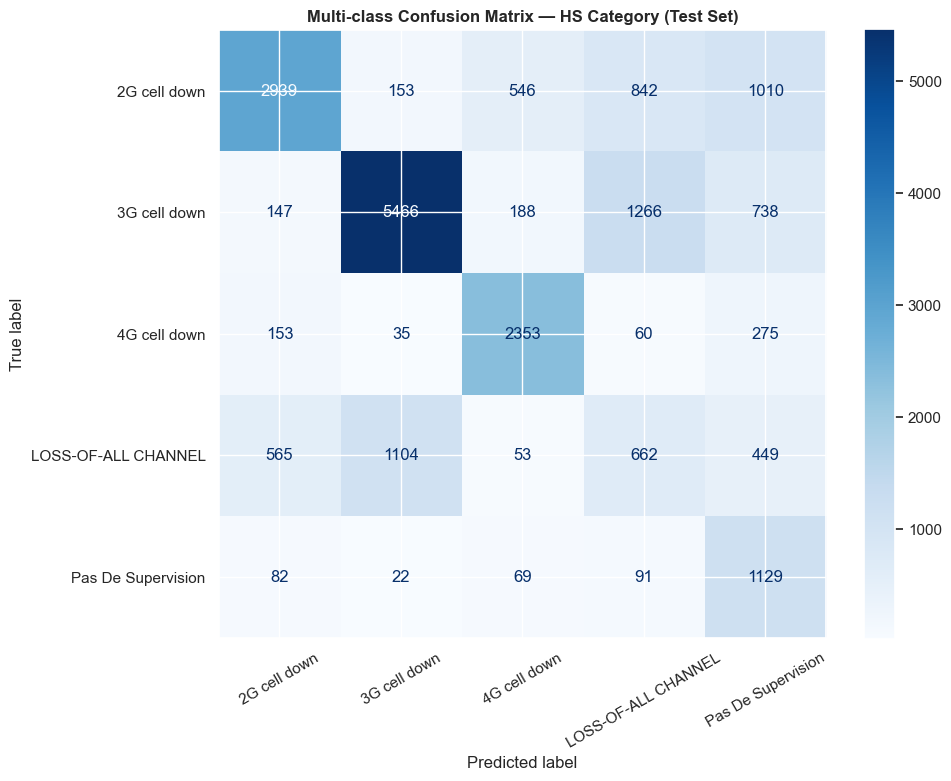

In [28]:
cm_mc = confusion_matrix(y_hs_te, y_hs_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_mc, display_labels=le_cat.classes_).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('Multi-class Confusion Matrix — HS Category (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'pred_multiclass_cm.png', dpi=150)
plt.show()

## 15. Save Model & Artefacts

In [29]:
save_model(
    model                = model,
    top_precursor_alarms = top_precursor_alarms,
    feature_names        = X.columns.tolist(),
    threshold            = best_threshold,
    output_dir           = MODELS_DIR,
    name                 = 'hs_binary_predictor',
)

joblib.dump(
    {'model': cat_model, 'label_encoder': le_cat,
     'feature_names': X_hs.columns.tolist()},
    MODELS_DIR + 'hs_category_predictor.joblib'
)
print('Saved → hs_category_predictor.joblib')

top_feats.to_csv(FEATURES_DIR + 'shap_feature_importance.csv', index=False)
print('Saved → shap_feature_importance.csv')

test_df[['Alarmname','codesite','Occurrencetime','hs_category',
         'y_true','hs_proba','hs_predicted']].to_csv(
    FEATURES_DIR + 'test_predictions.csv', index=False)
print('Saved → test_predictions.csv')

Model saved → ../models/hs_binary_predictor.joblib
Saved → hs_category_predictor.joblib
Saved → shap_feature_importance.csv
Saved → test_predictions.csv


## 16. Inference Demo

In [30]:
loaded_model, meta = load_model(MODELS_DIR + 'hs_binary_predictor.joblib')

# Last 500 events from test portion — use df (same sorted index as X)
new_raw     = df.iloc[val_end:].iloc[-500:].copy()
new_rolling = rolling_feat.loc[new_raw.index]

predictions = predict_hs(new_raw, loaded_model, meta,
                         precomputed_rolling=new_rolling)

print(f'Batch size          : {len(predictions):,}')
print(f'Predicted HS alarms : {predictions["hs_predicted"].sum()}')
predictions[['Alarmname','codesite','Occurrencetime',
             'is_HS','hs_proba','hs_predicted']].head(10)

Batch size          : 500
Predicted HS alarms : 59


,Alarmname,codesite,Occurrencetime,is_HS,hs_proba,hs_predicted
2235753,X2 Interface Fault,C25X038,2025-06-15 14:23:05+01:00,False,0.193394,0
2235754,X2 Interface Fault,C25X171,2025-06-15 14:23:05+01:00,False,0.193394,0
2235755,X2 Interface Fault,C25X407,2025-06-15 14:23:05+01:00,False,0.193394,0
2235756,X2 Interface Fault,3C25X226,2025-06-15 14:23:05+01:00,False,0.193394,0
2235757,X2 Interface Fault,3C25X139,2025-06-15 14:23:05+01:00,False,0.196417,0
2235758,X2 Interface Fault,C25X023,2025-06-15 14:23:05+01:00,False,0.193394,0
2235759,Configured Capacity Limit Exceeding Licensed L...,C34X195,2025-06-15 14:23:09+01:00,False,0.292588,0
2235760,LAPD Link Congestion,BCL1H,2025-06-15 14:23:09+01:00,False,0.887400,1
2235761,Local Cell Unusable,C34X195,2025-06-15 14:23:09+01:00,False,0.265350,0
2235762,Cell PS Service Faulty,A44X240,2025-06-15 14:23:20+01:00,False,0.165426,0


## 17. Summary

In [31]:
import glob

print('='*60)
print('PHASE 4 — PREDICTION COMPLETE')
print('='*60)
print(f'  Best model        : {best_model_name}')
print(f'  Threshold (F2)    : {best_threshold:.4f}')
print(f'  Test ROC-AUC      : {test_metrics["roc_auc"]:.4f}')
print(f'  Test PR-AUC       : {test_metrics["pr_auc"]:.4f}')
print(f'  Test F2  (HS)     : {test_metrics["f2_hs"]:.4f}')
print(f'  Test Recall (HS)  : {test_metrics["recall_hs"]:.4f}')
print(f'  Test Precision(HS): {test_metrics["precision_hs"]:.4f}')
print()
for f in sorted(glob.glob(MODELS_DIR + '*.joblib')):
    print(f'  {os.path.basename(f)}')
print('='*60)

PHASE 4 — PREDICTION COMPLETE
  Best model        : LightGBM
  Threshold (F2)    : 0.8657
  Test ROC-AUC      : 0.9251
  Test PR-AUC       : 0.6746
  Test F2  (HS)     : 0.6502
  Test Recall (HS)  : 0.6413
  Test Precision(HS): 0.6883

  hs_binary_predictor.joblib
  hs_category_predictor.joblib
